<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
!pip install -q \
    gdown \
    torch \
    "transformers<5" \
    accelerate \
    bitsandbytes \
    sentence-transformers \
    faiss-cpu \
    openpyxl \
    datasets \
    ragatouille \
    umap-learn \
    "langchain-core==0.3.79" \
    "langchain-community==0.3.31" \
    chromadb \
    langchain-text-splitters \
    sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 762.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.8/449.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0

In [1]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain_core.documents import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from ragatouille import RAGPretrainedModel

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

/tmp/ipykernel_11483/3894861673.py:17: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


## Загрузка данных (4 балла)

In [2]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=59ab2515-237f-45db-b6ef-e8f8da94b66d
To: /content/file.csv
100%|██████████| 672M/672M [00:13<00:00, 51.5MB/s]


In [3]:
data.sample(5)

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
8022,1271,Концертный зал им. С. И. Танеева,NaN,Владимир,40.384872,56.121651,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,the logo for the russian opera
6281,3135,Церковь Александра Невского в Сормово,Q16715547,Нижний Новгород,43.868862,56.357773,Церковь Александра Невского в Сормово,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed black and white photo of a crowd of peo...
5344,2118,Георгиевская башня,Q27781792,Нижний Новгород,44.008911,56.330097,башня Нижегородского кремля,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a young girl standing on a bench in f...
707,707,"Здание бывшей гостиницы ""Мадрид""",Q106150540,Екатеринбург,60.588634,56.886154,гостиница в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed picture of a large building with a cloc...
8597,2098,Владимир,NaN,Владимир,40.309170,56.107956,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a large white building with gold domes in a park


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [4]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [5]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

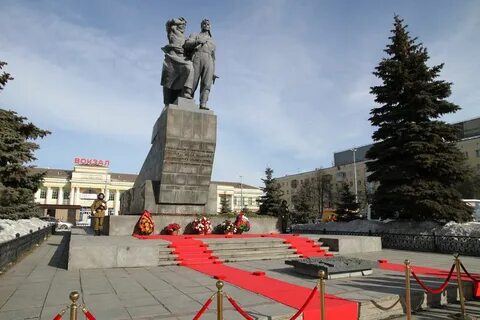

In [6]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [7]:
# your code here

#### Размер датасета

In [8]:
len(data)

14634

#### Колличество объектов

In [9]:
len(data.groupby(['Name', 'City', 'Lat', 'Lon']))

399

<Axes: >

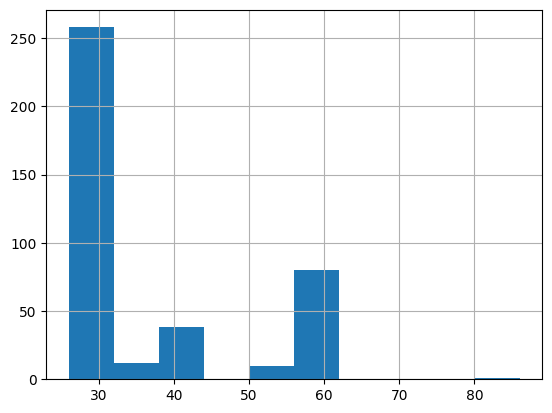

In [10]:
# Распределение числа описаний на объект
data.groupby(['Name', 'City', 'Lat', 'Lon'])['en_txt'].count().hist()

In [11]:
len(data[data['description'].isna()])

2556

#### TF-IDF по описаниям

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

texts = (
    data["en_txt"]
    .dropna()
    .astype(str)
    .str.strip()
)

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=1,
    max_df=0.9
)

X = vectorizer.fit_transform(texts)
terms = vectorizer.get_feature_names_out()

mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
max_tfidf = X.max(axis=0).toarray().ravel()

tfidf_df = pd.DataFrame({
    "word": terms,
    "mean_tfidf": mean_tfidf,
    "max_tfidf": max_tfidf,
})

print("Топ слов по max TF-IDF:")
display(tfidf_df.sort_values("max_tfidf", ascending=False).head(20).reset_index(drop=True))

Топ слов по max TF-IDF:


,word,mean_tfidf,max_tfidf
0,прррмомоннннннннннн,0.000068,1.000000
1,picture,0.013627,1.000000
2,balcony,0.003361,0.989712
3,crane,0.000473,0.975751
4,satellite,0.000101,0.973912
5,spire,0.001085,0.970614
6,television,0.000409,0.967675
7,chimney,0.000631,0.964804
8,statues,0.002673,0.961873
9,piano,0.001795,0.956000


In [13]:
import re

top_k = 20

# берём топ-20 слов по max_tfidf
top_words = (
    tfidf_df
    .sort_values("max_tfidf", ascending=False)
    ["word"]
    .head(top_k)
    .tolist()
)

print("Топ-30 слов по max_tfidf:")
print(top_words)

# regex для поиска целых слов
pattern = r"\b(?:{})\b".format("|".join(map(re.escape, top_words)))

# маска строк, где en_txt содержит хотя бы одно из этих слов
mask_bad = (
    data["en_txt"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.contains(pattern, regex=True)
)

filtered_out_count = mask_bad.sum()
clean_data = data.loc[~mask_bad].copy()
data = data.loc[mask_bad].copy()

print(f"Отфильтровано объектов: {filtered_out_count}")
print(f"Осталось объектов: {len(clean_data)}")

Топ-30 слов по max_tfidf:
['прррмомоннннннннннн', 'picture', 'balcony', 'crane', 'satellite', 'spire', 'television', 'chimney', 'statues', 'piano', 'columns', 'clock', 'face', 'drawing', 'truck', 'vase', 'tree', 'banner', 'scaffolding', 'steeple']
Отфильтровано объектов: 4065
Осталось объектов: 10569


#### Оставим только по одному описанию максимальной длины для каждого объекта

In [14]:
def first_non_null(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else None

def longest_non_empty_text(series):
    s = (
        series.dropna()
        .astype(str)
        .str.strip()
    )
    s = s[s != ""]
    if len(s) == 0:
        return None
    return s.iloc[s.str.len().argmax()]

grouped_data = (
    data
    .groupby(["Name", "City", "Lat", "Lon"], dropna=False, as_index=False)
    .agg(
        WikiData=("WikiData", first_non_null),
        description_best=("description", longest_non_empty_text),
        en_txt_best=("en_txt", longest_non_empty_text),
        image=("image", first_non_null),
        group_size=("Name", "size"),
    )
    .reset_index(drop=True)
)

grouped_data["source_id"] = np.arange(len(grouped_data))

print(f"Количество строк в исходном датасете: {len(data)}")
print(f"Количество уникальных объектов после группировки: {len(grouped_data)}")

display(grouped_data.head())

Количество строк в исходном датасете: 4065
Количество уникальных объектов после группировки: 386


,Name,City,Lat,Lon,WikiData,description_best,en_txt_best,image,group_size,source_id
0,1941-1945,Владимир,56.111187,40.362949,None,None,arafed book with a picture of a man climbing a...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,6,0
1,2000 летию Рождества Христова,Владимир,56.127674,40.408882,None,None,there is a small wooden church with a green st...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,13,1
2,Cerkiew Narodzenia Pańskiego w Jarosławiu,Ярославль,57.630562,39.894360,Q28058985,Православный храм в Ярославле,arafed wooden building with a steeple and a st...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,20,2
3,Cerkiew Włodzimierskiej Ikony Matki Bożej w Ja...,Ярославль,57.611237,39.906563,Q30913943,Архитектурный ансамбль в Ярославле,arafed view of a church with a clock tower in ...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,20,3
4,Cerkiew św. Dymitra Sołuńskiego w Jarosławiu,Ярославль,57.621670,39.881390,Q28056804,Церковь великомученика Димитрия Солунского (См...,arafed wooden church with steeple and steeple ...,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,30,4


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [15]:
# your code here

#### Собираем корпус для RAG

In [16]:
from langchain_core.documents import Document as LangchainDocument
from tqdm.notebook import tqdm

def build_page_content(row):
    parts = [
        f"landmark_name: {row['Name']}",
        f"city: {row['City']}",
    ]

    if pd.notna(row["description_best"]):
        parts.append(f"wikidata_description_ru: {row['description_best']}")

    if pd.notna(row["en_txt_best"]):
        parts.append(f"image_caption_en: {row['en_txt_best']}")

    if pd.notna(row["Lat"]) and pd.notna(row["Lon"]):
        parts.append(f"coordinates: latitude {row['Lat']}, longitude {row['Lon']}")

    return "\n".join(parts)

RAW_KNOWLEDGE_BASE = []
IMAGE_BY_SOURCE = {}

for _, row in tqdm(grouped_data.iterrows(), total=len(grouped_data)):
    source_id = int(row["source_id"])

    RAW_KNOWLEDGE_BASE.append(
        LangchainDocument(
            page_content=build_page_content(row),
            metadata={
                "source_id": source_id,
                "name": row["Name"],
                "city": row["City"],
                "lat": None if pd.isna(row["Lat"]) else float(row["Lat"]),
                "lon": None if pd.isna(row["Lon"]) else float(row["Lon"]),
                "wikidata": row["WikiData"] if pd.notna(row["WikiData"]) else None,
                "group_size": int(row["group_size"]),
            },
        )
    )

    IMAGE_BY_SOURCE[source_id] = row["image"]

print(f"Количество документов в базе знаний: {len(RAW_KNOWLEDGE_BASE)}")
print(RAW_KNOWLEDGE_BASE[0].page_content)
print(RAW_KNOWLEDGE_BASE[0].metadata)

  0%|          | 0/386 [00:00<?, ?it/s]

Количество документов в базе знаний: 386
landmark_name: 1941-1945
city: Владимир
image_caption_en: arafed book with a picture of a man climbing a mountain
coordinates: latitude 56.111187, longitude 40.362949
{'source_id': 0, 'name': '1941-1945', 'city': 'Владимир', 'lat': 56.111187, 'lon': 40.362949, 'wikidata': None, 'group_size': 6}


#### Разбиваем на чанки и строим базу Chroma

In [17]:
import os
import shutil
import torch

from typing import List
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain_core.embeddings import Embeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma

EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-small"
CHROMA_DIR = "./chroma_landmarks_db"

MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",
    "```\n",
    "\n\\*\\*\\*+\n",
    "\n---+\n",
    "\n___+\n",
    "\n\n",
    "\n",
    " ",
    "",
]

class E5Embeddings(Embeddings):
    def __init__(self, model_name: str, device: str = None):
        self.model_name = model_name
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = SentenceTransformer(model_name, device=self.device)

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        texts = [f"passage: {text}" for text in texts]
        embeddings = self.model.encode(
            texts,
            normalize_embeddings=True,
            show_progress_bar=True,
            batch_size=64,
        )
        return embeddings.tolist()

    def embed_query(self, text: str) -> List[float]:
        embedding = self.model.encode(
            [f"query: {text}"],
            normalize_embeddings=True,
            show_progress_bar=False,
        )
        return embedding[0].tolist()

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)

text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer=tokenizer,
    chunk_size=256,
    chunk_overlap=32,
    add_start_index=True,
    strip_whitespace=True,
    separators=MARKDOWN_SEPARATORS,
)

docs_processed = []
for doc in tqdm(RAW_KNOWLEDGE_BASE):
    docs_processed.extend(text_splitter.split_documents([doc]))

# удаляем дубли по тексту чанка
seen = set()
docs_processed_unique = []
for doc in docs_processed:
    if doc.page_content not in seen:
        seen.add(doc.page_content)
        docs_processed_unique.append(doc)

docs_processed = docs_processed_unique

print(f"Количество чанков после разбиения и dedup: {len(docs_processed)}")

embedding_model = E5Embeddings(EMBEDDING_MODEL_NAME)

if os.path.exists(CHROMA_DIR):
    shutil.rmtree(CHROMA_DIR)

KNOWLEDGE_VECTOR_DATABASE = Chroma.from_documents(
    documents=docs_processed,
    embedding=embedding_model,
    collection_name="landmarks_rag",
    persist_directory=CHROMA_DIR,
    collection_metadata={"hnsw:space": "cosine"},
)

print("Chroma index built successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Chroma index built successfully.


#### Добавляем Reader и Reranker

In [18]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from ragatouille import RAGPretrainedModel

READER_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

if torch.cuda.is_available():
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    reader_model = AutoModelForCausalLM.from_pretrained(
        READER_MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
    )
else:
    reader_model = AutoModelForCausalLM.from_pretrained(
        READER_MODEL_NAME,
        torch_dtype=torch.float32,
        device_map="cpu",
    )

reader_tokenizer = AutoTokenizer.from_pretrained(READER_MODEL_NAME)
if reader_tokenizer.pad_token is None:
    reader_tokenizer.pad_token = reader_tokenizer.eos_token

READER_LLM = pipeline(
    task="text-generation",
    model=reader_model,
    tokenizer=reader_tokenizer,
    do_sample=False,
    temperature=None,
    repetition_penalty=1.05,
    return_full_text=False,
    max_new_tokens=256,
)

RERANKER = RAGPretrainedModel.from_pretrained("colbert-ir/colbertv2.0")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[Apr 27, 11:11:22] Loading segmented_maxsim_cpp extension (set COLBERT_LOAD_TORCH_EXTENSION_VERBOSE=True for more info)...


/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(


#### Полный пайплайн: HyDE + retrieval + reranking + answer generation

In [19]:
from collections import defaultdict
from typing import Optional, List, Tuple

def generate_with_llm(messages, max_new_tokens=192):
    prompt = reader_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    return READER_LLM(prompt, max_new_tokens=max_new_tokens)[0]["generated_text"].strip()

def generate_hyde_document(question: str) -> str:
    messages = [
        {
            "role": "system",
            "content": (
                "You write short factual passages for retrieval. "
                "Given a user question about a landmark, monument, building, museum, church, tower, or tourist place, "
                "produce a compact descriptive passage that could plausibly appear in a reference database. "
                "Do not mention that this is hypothetical."
            ),
        },
        {
            "role": "user",
            "content": question,
        },
    ]
    return generate_with_llm(messages, max_new_tokens=160)

def reciprocal_rank_fusion(results_lists: List[List[LangchainDocument]], rrf_k: int = 60) -> List[LangchainDocument]:
    scores = defaultdict(float)
    doc_map = {}

    for docs in results_lists:
        for rank, doc in enumerate(docs, start=1):
            key = (
                doc.metadata.get("source_id"),
                doc.metadata.get("start_index", -1),
                doc.page_content,
            )
            scores[key] += 1.0 / (rrf_k + rank)
            doc_map[key] = doc

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return [doc_map[key] for key, _ in ranked]

def retrieve_with_hyde(
    question: str,
    knowledge_index: Chroma,
    num_retrieved_docs: int = 20,
) -> Tuple[List[LangchainDocument], str]:
    hyde_doc = generate_hyde_document(question)

    docs_from_question = knowledge_index.similarity_search(question, k=num_retrieved_docs)
    docs_from_hyde = knowledge_index.similarity_search(hyde_doc, k=num_retrieved_docs)

    fused_docs = reciprocal_rank_fusion([docs_from_question, docs_from_hyde])
    return fused_docs[:num_retrieved_docs], hyde_doc

def rerank_documents(
    question: str,
    docs: List[LangchainDocument],
    reranker: Optional[RAGPretrainedModel] = None,
    num_docs_final: int = 5,
) -> List[LangchainDocument]:
    if reranker is None:
        return docs[:num_docs_final]

    text_to_doc = {doc.page_content: doc for doc in docs}
    candidate_texts = [doc.page_content for doc in docs]

    reranked = reranker.rerank(question, candidate_texts, k=num_docs_final)
    final_docs = [text_to_doc[item["content"]] for item in reranked]

    return final_docs

def build_context(docs: List[LangchainDocument]) -> str:
    blocks = []
    for i, doc in enumerate(docs):
        blocks.append(
            f"Document {i}\n"
            f"source_id: {doc.metadata.get('source_id')}\n"
            f"name: {doc.metadata.get('name')}\n"
            f"city: {doc.metadata.get('city')}\n"
            f"text:\n{doc.page_content}\n"
        )
    return "\n---\n".join(blocks)

def answer_with_rag(
    question: str,
    llm,
    knowledge_index: Chroma,
    reranker: Optional[RAGPretrainedModel] = None,
    num_retrieved_docs: int = 20,
    num_docs_final: int = 5,
):
    print("=> Generating HyDE document and retrieving...")
    retrieved_docs, hyde_doc = retrieve_with_hyde(
        question=question,
        knowledge_index=knowledge_index,
        num_retrieved_docs=num_retrieved_docs,
    )

    print("=> Reranking with ragatouille...")
    final_docs = rerank_documents(
        question=question,
        docs=retrieved_docs,
        reranker=reranker,
        num_docs_final=num_docs_final,
    )

    context = build_context(final_docs)

    messages = [
        {
            "role": "system",
            "content": (
                "Answer using only the provided context. "
                "If the answer is not supported by the context, say that there is not enough information. "
                "Answer in the same language as the user's question. "
                "Be concise but informative. "
                "When relevant, mention source_id and the object name."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Context:\n{context}\n\n"
                f"Question: {question}"
            ),
        },
    ]

    print("=> Generating answer...")
    answer = generate_with_llm(messages, max_new_tokens=220)

    return answer, final_docs, hyde_doc

#### Пример использования

In [20]:
question = "Что это может быть за место в Ярославле с церковью и зелёными куполами?"

answer, relevant_docs, hyde_doc = answer_with_rag(
    question=question,
    llm=READER_LLM,
    knowledge_index=KNOWLEDGE_VECTOR_DATABASE,
    reranker=RERANKER,
    num_retrieved_docs=20,
    num_docs_final=5,
)

print("================================== HyDE ==================================")
print(hyde_doc)

print("\n================================= Answer =================================")
print(answer)

print("\n============================== Source docs ================================")
for i, doc in enumerate(relevant_docs):
    print(f"\nDocument {i}")
    print(f"source_id: {doc.metadata.get('source_id')}")
    print(f"name: {doc.metadata.get('name')}")
    print(f"city: {doc.metadata.get('city')}")
    print(doc.page_content)

=> Generating HyDE document and retrieving...
=> Reranking with ragatouille...


/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
100%|██████████| 1/1 [00:07<00:00,  7.35s/it]


=> Generating answer...
================================== HyDE ==================================
Это Ярославский собор, один из самых старых и известных храмов в Ярославле. Он был построен в 12 веке и является символом города. Собор украшен зелёными куполами, которые добавляют особый шарм и красоте. Внутри храма можно увидеть уникальные статуи и росписи, а также воспоминания о древних правителях Ярославля.

================================= Answer =================================
Музей древнерусского искусства.

============================== Source docs ================================

Document 0
source_id: 193
name: Музыка и время
city: Ярославль
landmark_name: Музыка и время
city: Ярославль
wikidata_description_ru: Частный музей
image_caption_en: there is a tall building with a balcony and a balcony on the second floor
coordinates: latitude 57.630356, longitude 39.894951

Document 1
source_id: 264
name: Старообрядческий храм Иоанна Златоуста в Коровниках
city: Ярославль
landmark

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [21]:
# your code here

In [22]:
from sklearn.decomposition import PCA
import umap.umap_ as umap
import numpy as np
import pandas as pd
import plotly.express as px

user_query = "Что это может быть за место в Ярославле с церковью и зелёными куполами?"

# если эмбеддинги документов ещё не посчитаны — считаем
if "DOC_EMBEDDINGS" not in globals():
    DOC_EMBEDDINGS = np.array(
        embedding_model.embed_documents([doc.page_content for doc in docs_processed]),
        dtype=np.float32,
    )

query_vector = np.array(embedding_model.embed_query(user_query), dtype=np.float32)

# объединяем документы + запрос
all_embeddings = np.vstack([DOC_EMBEDDINGS, query_vector[None, :]])

print("Форма матрицы эмбеддингов:", all_embeddings.shape)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Форма матрицы эмбеддингов: (387, 384)


In [23]:
city_series = pd.Series([doc.metadata.get("city", "unknown") for doc in docs_processed]).fillna("unknown")
top_cities = set(city_series.value_counts().head(10).index)

def city_group(city):
    if city in top_cities:
        return city
    return "other"

def make_projection_df(projected_embeddings, docs, user_query):
    rows = []

    for i, doc in enumerate(docs):
        city = doc.metadata.get("city", "unknown")
        rows.append(
            {
                "x": projected_embeddings[i, 0],
                "y": projected_embeddings[i, 1],
                "name": doc.metadata.get("name", ""),
                "city": city,
                "city_group": city_group(city),
                "source_id": doc.metadata.get("source_id", -1),
                "extract": doc.page_content[:200] + ("..." if len(doc.page_content) > 200 else ""),
                "symbol": "document",
                "size_col": 6,
            }
        )

    rows.append(
        {
            "x": projected_embeddings[-1, 0],
            "y": projected_embeddings[-1, 1],
            "name": "user query",
            "city": "user query",
            "city_group": "user query",
            "source_id": -1,
            "extract": user_query,
            "symbol": "query",
            "size_col": 18,
        }
    )

    return pd.DataFrame(rows)

In [24]:
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(all_embeddings)

df_pca = make_projection_df(embeddings_pca, docs_processed, user_query)

explained_var = pca.explained_variance_ratio_.sum()

fig = px.scatter(
    df_pca,
    x="x",
    y="y",
    color="city_group",
    symbol="symbol",
    size="size_col",
    hover_data=["name", "city", "source_id", "extract"],
    width=1100,
    height=750,
    title=f"2D-проекция эмбеддингов с помощью PCA (explained variance = {explained_var:.3f})",
    color_discrete_map={"user query": "black"},
)

fig.update_traces(
    marker=dict(opacity=0.8, line=dict(width=0)),
    selector=dict(mode="markers"),
)

fig.show()

In [25]:
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

embeddings_umap = umap_reducer.fit_transform(all_embeddings)

df_umap = make_projection_df(embeddings_umap, docs_processed, user_query)

fig = px.scatter(
    df_umap,
    x="x",
    y="y",
    color="city_group",
    symbol="symbol",
    size="size_col",
    hover_data=["name", "city", "source_id", "extract"],
    width=1100,
    height=750,
    title="2D-проекция эмбеддингов с помощью UMAP",
    color_discrete_map={"user query": "black"},
)

fig.update_traces(
    marker=dict(opacity=0.8, line=dict(width=0)),
    selector=dict(mode="markers"),
)

fig.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [26]:
retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(user_query, k=5)

retrieved_df = pd.DataFrame(
    [
        {
            "rank": i + 1,
            "source_id": doc.metadata.get("source_id"),
            "name": doc.metadata.get("name"),
            "city": doc.metadata.get("city"),
            "text": doc.page_content[:250] + ("..." if len(doc.page_content) > 250 else ""),
        }
        for i, doc in enumerate(retrieved_docs)
    ]
)

display(retrieved_df)

,rank,source_id,name,city,text
0,1,373,церковь Николая Чудотворца,Ярославль,landmark_name: церковь Николая Чудотворца\ncit...
1,2,206,Николая Чудотворца,Ярославль,landmark_name: Николая Чудотворца\ncity: Яросл...
2,3,374,церковь Николы Рублёного,Ярославль,landmark_name: церковь Николы Рублёного\ncity:...
3,4,147,Колокольня Никитского прихода,Ярославль,landmark_name: Колокольня Никитского прихода\n...
4,5,338,Церковь Софии Премудрости Божией в Савино,Ярославль,landmark_name: Церковь Софии Премудрости Божие...


# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

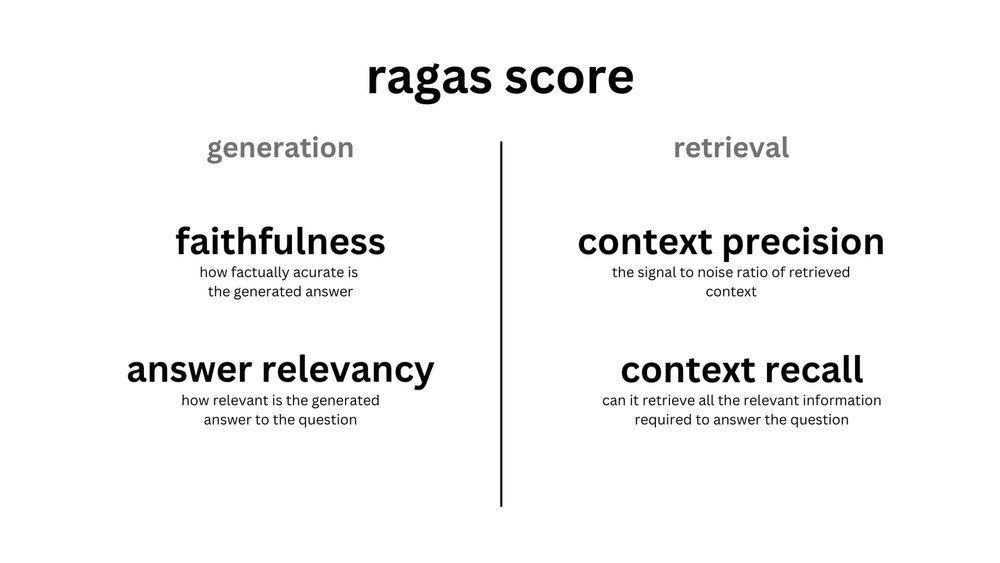

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

#### Data preprocess

In [28]:
import re
import numpy as np
import pandas as pd

from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer


def _safe_str(x):
    if x is None:
        return ""
    if isinstance(x, float) and pd.isna(x):
        return ""
    return str(x).strip()


def _build_ground_truth(row):
    parts = []

    name = _safe_str(row.get("Name"))
    city = _safe_str(row.get("City"))
    description_ru = _safe_str(row.get("description_best"))
    caption_en = _safe_str(row.get("en_txt_best"))
    lat = row.get("Lat")
    lon = row.get("Lon")

    if name:
        parts.append(f"The place is {name}.")
    if city:
        parts.append(f"It is located in {city}.")
    if description_ru:
        parts.append(f"Description: {description_ru}.")
    if caption_en:
        parts.append(f"Image-based description: {caption_en}.")
    if pd.notna(lat) and pd.notna(lon):
        parts.append(f"Coordinates: latitude {lat}, longitude {lon}.")

    return " ".join(parts).strip()


def _clean_generated_question(text):
    text = _safe_str(text)
    text = text.split("\n")[0]
    text = re.sub(r"^[\-\*\d\.\)\s]+", "", text)
    text = text.strip("\"' ")
    return text


def _parse_generated_questions(text, n=3):
    lines = [line.strip() for line in _safe_str(text).split("\n")]
    lines = [re.sub(r"^[\-\*\d\.\)\s]+", "", line).strip() for line in lines]
    lines = [line for line in lines if line]
    return lines[:n]


def generate_question_from_row(row, llm_generate_fn):
    context = _build_ground_truth(row)

    messages = [
        {
            "role": "system",
            "content": (
                "You create one short user question for a tourism QA dataset. "
                "The question must be answerable from the given description. "
                "Prefer natural questions about a landmark or place. "
                "Do not make the question too long. "
                "Return only one question."
            ),
        },
        {
            "role": "user",
            "content": f"Description:\n{context}",
        },
    ]

    question = llm_generate_fn(messages, max_new_tokens=64)
    question = _clean_generated_question(question)

    if not question:
        name = _safe_str(row.get("Name"))
        city = _safe_str(row.get("City"))
        caption_en = _safe_str(row.get("en_txt_best"))
        question = f"What place in {city} could be described as: {caption_en}?"
        if not city:
            question = f"What place could be described as: {caption_en}?"
        if not caption_en and name:
            question = f"What can you tell me about {name}?"

    return question


def data_preprocess(
    df_objects: pd.DataFrame,
    sample_size: int = 100,
    random_state: int = 42,
    llm_generate_fn=None,
    rag_answer_fn=None,
    llm=None,
    knowledge_index=None,
    reranker=None,
    num_retrieved_docs: int = 10,
    num_docs_final: int = 5,
):
    """
    Подготавливает датафрейм формата:
    question, ground_truths, answer, contexts
    """
    if llm_generate_fn is None:
        raise ValueError("llm_generate_fn must be provided")
    if rag_answer_fn is None:
        raise ValueError("rag_answer_fn must be provided")
    if llm is None:
        raise ValueError("llm must be provided")
    if knowledge_index is None:
        raise ValueError("knowledge_index must be provided")

    df = df_objects.copy()

    # оставим только строки, где есть хоть какой-то текст
    mask_valid = (
        df["en_txt_best"].fillna("").astype(str).str.strip().ne("")
        | df["description_best"].fillna("").astype(str).str.strip().ne("")
    )
    df = df.loc[mask_valid].reset_index(drop=True)

    sample_size = min(sample_size, len(df))
    df = df.sample(sample_size, random_state=random_state).reset_index(drop=True)

    records = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        question = generate_question_from_row(row, llm_generate_fn=llm_generate_fn)
        ground_truth = _build_ground_truth(row)

        try:
            answer, retrieved_docs, _ = rag_answer_fn(
                question=question,
                llm=llm,
                knowledge_index=knowledge_index,
                reranker=reranker,
                num_retrieved_docs=num_retrieved_docs,
                num_docs_final=num_docs_final,
            )
            contexts = [doc.page_content for doc in retrieved_docs]
        except Exception as e:
            answer = ""
            contexts = []
            print(f"Error on question: {question}\n{e}\n")

        records.append(
            {
                "question": question,
                "ground_truths": [ground_truth],
                "answer": answer,
                "contexts": contexts,
                "object_name": row.get("Name"),
                "city": row.get("City"),
                "source_id": row.get("source_id"),
            }
        )

    return pd.DataFrame(records)

#### Answer relevancy

In [29]:
def generate_reverse_questions_from_answer(answer, llm_generate_fn, n_questions=3):
    if not _safe_str(answer):
        return []

    messages = [
        {
            "role": "system",
            "content": (
                f"You are evaluating QA quality. "
                f"Given an answer, generate {n_questions} different questions "
                f"for which this answer would be relevant. "
                f"Return exactly {n_questions} short questions, one per line, without explanations."
            ),
        },
        {
            "role": "user",
            "content": f"Answer:\n{answer}",
        },
    ]

    raw_output = llm_generate_fn(messages, max_new_tokens=128)
    questions = _parse_generated_questions(raw_output, n=n_questions)

    return questions


def _cosine_similarity_matrix(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)

    a_norm = a / np.clip(np.linalg.norm(a, axis=1, keepdims=True), 1e-12, None)
    b_norm = b / np.clip(np.linalg.norm(b, axis=1, keepdims=True), 1e-12, None)

    return a_norm @ b_norm.T


def answer_relevancy(
    df_eval: pd.DataFrame,
    llm_generate_fn=None,
    embedding_model_name: str = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    n_questions: int = 3,
    return_details: bool = True,
):
    """
    Реализация answer_relevancy в духе RAGAS:
    1) из answer генерируем n_questions обратных вопросов,
    2) считаем cosine similarity между ними и исходным question,
    3) усредняем.
    """
    if llm_generate_fn is None:
        raise ValueError("llm_generate_fn must be provided")

    embedder = SentenceTransformer(embedding_model_name)

    rows = []

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval)):
        question = _safe_str(row.get("question"))
        answer = _safe_str(row.get("answer"))

        if not question or not answer:
            rows.append(
                {
                    **row.to_dict(),
                    "generated_questions": [],
                    "answer_relevancy": np.nan,
                }
            )
            continue

        generated_questions = generate_reverse_questions_from_answer(
            answer=answer,
            llm_generate_fn=llm_generate_fn,
            n_questions=n_questions,
        )

        if len(generated_questions) == 0:
            rows.append(
                {
                    **row.to_dict(),
                    "generated_questions": [],
                    "answer_relevancy": np.nan,
                }
            )
            continue

        texts_to_embed = [question] + generated_questions
        embeddings = embedder.encode(
            texts_to_embed,
            normalize_embeddings=True,
            show_progress_bar=False,
        )

        question_embedding = embeddings[:1]
        generated_embeddings = embeddings[1:]

        sims = _cosine_similarity_matrix(generated_embeddings, question_embedding).ravel()
        score = float(np.mean(sims))

        rows.append(
            {
                **row.to_dict(),
                "generated_questions": generated_questions,
                "answer_relevancy": score,
            }
        )

    result_df = pd.DataFrame(rows)
    mean_score = float(result_df["answer_relevancy"].dropna().mean())

    if return_details:
        return result_df, mean_score

    return mean_score

# Протестируйте ваш RAG (3 балла)

In [30]:
# your code here

In [31]:
eval_df = data_preprocess(
    df_objects=grouped_data,
    sample_size=20,
    random_state=42,
    llm_generate_fn=generate_with_llm,
    rag_answer_fn=answer_with_rag,
    llm=READER_LLM,
    knowledge_index=KNOWLEDGE_VECTOR_DATABASE,
    reranker=RERANKER,
    num_retrieved_docs=10,
    num_docs_final=5,
)

display(eval_df.head())

  0%|          | 0/20 [00:00<?, ?it/s]

=> Generating HyDE document and retrieving...
=> Reranking with ragatouille...


/usr/local/lib/python3.12/dist-packages/colbert/utils/amp.py:15: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.

/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning:

CUDA is not available or torch_xla is imported. Disabling autocast.


100%|██████████| 1/1 [00:05<00:00,  5.38s/it]


=> Generating answer...
=> Generating HyDE document and retrieving...
=> Reranking with ragatouille...



100%|██████████| 1/1 [00:04<00:00,  4.22s/it]


...


100%|██████████| 1/1 [00:04<00:00,  4.49s/it]


=> Generating answer...
=> Generating HyDE document and retrieving...
=> Reranking with ragatouille...



100%|██████████| 1/1 [00:03<00:00,  3.68s/it]


=> Generating answer...


,question,ground_truths,answer,contexts,object_name,city,source_id
0,What is the name of the church?,[The place is Церковь Рождества Христова. It i...,Храм на Крови,[landmark_name: Храм на Крови\ncity: Екатеринб...,Церковь Рождества Христова,Владимир,336
1,What is the name of the place?,[The place is Храм Великомученика Никиты. It i...,"The name of the place is ""Концертный зал им. С...",[landmark_name: Концертный зал им. С. И. Танее...,Храм Великомученика Никиты,Ярославль,307
2,What is the name of the building?,[The place is Дом Е. Трушенинниковой. It is lo...,"The landmark name for all documents is ""Концер...",[landmark_name: Концертный зал им. С. И. Танее...,Дом Е. Трушенинниковой,Нижний Новгород,90
3,What is the name of the place?,[The place is Старый Владимир. It is located i...,"The name of the place is ""Концертный зал им. С...",[landmark_name: Концертный зал им. С. И. Танее...,Старый Владимир,Владимир,265
4,What is the name of the place?,[The place is Концертно-спортивный комплекс Ar...,"The name of the place is ""Концертный зал им. С...",[landmark_name: Концертный зал им. С. И. Танее...,Концертно-спортивный комплекс Art Hall,Владимир,150


In [32]:
scored_df, mean_answer_relevancy = answer_relevancy(
    df_eval=eval_df,
    llm_generate_fn=generate_with_llm,
    embedding_model_name="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    n_questions=3,
    return_details=True,
)

print(f"mean answer_relevancy: {mean_answer_relevancy:.4f}")
display(
    scored_df[
        ["question", "answer", "generated_questions", "answer_relevancy", "object_name", "city"]
    ].head()
)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  0%|          | 0/20 [00:00<?, ?it/s]

mean answer_relevancy: 0.6745


,question,answer,generated_questions,answer_relevancy,object_name,city
0,What is the name of the church?,Храм на Крови,[What is the name of the church located on the...,0.716500,Церковь Рождества Христова,Владимир
1,What is the name of the place?,"The name of the place is ""Концертный зал им. С...",[What is the official name of the concert hall...,0.487622,Храм Великомученика Никиты,Ярославль
2,What is the name of the building?,"The landmark name for all documents is ""Концер...",[What is the official name of the concert hall...,0.626283,Дом Е. Трушенинниковой,Нижний Новгород
3,What is the name of the place?,"The name of the place is ""Концертный зал им. С...",[What is the official name of the concert hall...,0.487622,Старый Владимир,Владимир
4,What is the name of the place?,"The name of the place is ""Концертный зал им. С...",[What is the official name of the concert hall...,0.487622,Концертно-спортивный комплекс Art Hall,Владимир


In [33]:
print("Лучшие примеры:")
display(
    scored_df.sort_values("answer_relevancy", ascending=False)[
        ["question", "answer", "generated_questions", "answer_relevancy", "object_name", "city"]
    ].head(5)
)

print("Худшие примеры:")
display(
    scored_df.sort_values("answer_relevancy", ascending=True)[
        ["question", "answer", "generated_questions", "answer_relevancy", "object_name", "city"]
    ].head(5)
)

Лучшие примеры:


,question,answer,generated_questions,answer_relevancy,object_name,city
16,Where is the monument to Leonid Trefilov?,Not enough information to determine the locati...,[Where is the monument to Leonid Trefilov loca...,0.948503,Памятник Леониду Николаевичу Трефолеву,Ярославль
10,What is the name of the park?,"The park is named ""Власьевский сквер"".","[What is the name of the park?, Is there a par...",0.925098,Демидовский сад,Ярославль
11,What is the name of the building in EKaterinburg?,The landmark name for the building in EKaterin...,[What is the official name of the landmark in ...,0.888947,Дом Артистов,Екатеринбург
13,What is the name of the university?,"The university is named ""Уральский государстве...","[What is the official name of the university?,...",0.855730,Владимирский государственный гуманитарный унив...,Владимир
15,What is the name of the university?,"The university is named ""Уральский государстве...","[What is the official name of the university?,...",0.855730,Уральский государственный колледж имени И.И. П...,Екатеринбург


Худшие примеры:


,question,answer,generated_questions,answer_relevancy,object_name,city
1,What is the name of the place?,"The name of the place is ""Концертный зал им. С...",[What is the official name of the concert hall...,0.487622,Храм Великомученика Никиты,Ярославль
3,What is the name of the place?,"The name of the place is ""Концертный зал им. С...",[What is the official name of the concert hall...,0.487622,Старый Владимир,Владимир
6,What is the name of the place?,"The name of the place is ""Концертный зал им. С...",[What is the official name of the concert hall...,0.487622,Дмитриевский собор,Владимир
4,What is the name of the place?,"The name of the place is ""Концертный зал им. С...",[What is the official name of the concert hall...,0.487622,Концертно-спортивный комплекс Art Hall,Владимир
9,What is the name of the place?,"The name of the place is ""Концертный зал им. С...",[What is the official name of the concert hall...,0.487622,Владимир,Владимир


# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [34]:
# your code here

In [35]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm


def parse_yes_no(text: str) -> int:
    text = str(text).strip().lower()
    first_line = text.split("\n")[0].strip()

    if first_line.startswith("yes"):
        return 1
    if first_line.startswith("no"):
        return 0

    if "yes" in first_line and "no" not in first_line:
        return 1
    if "no" in first_line and "yes" not in first_line:
        return 0

    return 0


def judge_context_relevance(
    question: str,
    ground_truth: str,
    context: str,
    llm_generate_fn,
) -> int:
    messages = [
        {
            "role": "system",
            "content": (
                "You are evaluating retrieval quality for RAG. "
                "Given a question, a reference answer, and one retrieved context chunk, "
                "decide whether this context is relevant for answering the question correctly. "
                "A context is relevant if it contains information that helps answer the question "
                "and is consistent with the reference answer. "
                "Reply with only one word: Yes or No."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Question:\n{question}\n\n"
                f"Reference answer:\n{ground_truth}\n\n"
                f"Retrieved context:\n{context}\n\n"
                f"Is this context relevant?"
            ),
        },
    ]

    raw_output = llm_generate_fn(messages, max_new_tokens=8)
    return parse_yes_no(raw_output)

In [36]:
def average_precision_at_k(relevance_labels):
    """
    relevance_labels: список из 0/1 в порядке retrieved contexts
    """
    relevance_labels = list(relevance_labels)

    num_relevant = sum(relevance_labels)
    if num_relevant == 0:
        return 0.0

    precisions = []
    relevant_so_far = 0

    for rank, rel in enumerate(relevance_labels, start=1):
        if rel == 1:
            relevant_so_far += 1
            precisions.append(relevant_so_far / rank)

    return float(np.mean(precisions))

In [37]:
def context_precision(
    df_eval: pd.DataFrame,
    llm_generate_fn=None,
    max_contexts: int = 5,
    return_details: bool = True,
):
    """
    Ожидает в df_eval поля:
    - question
    - ground_truths  (список строк)
    - contexts       (список retrieved чанков)

    Для каждого примера:
    1) judge определяет релевантность каждого чанка,
    2) считаем Average Precision по порядку retrieved contexts,
    3) усредняем по датасету.
    """
    if llm_generate_fn is None:
        raise ValueError("llm_generate_fn must be provided")

    rows = []

    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval)):
        question = str(row.get("question", "")).strip()
        ground_truths = row.get("ground_truths", [])
        contexts = row.get("contexts", [])

        if not question or not isinstance(contexts, list) or len(contexts) == 0:
            rows.append(
                {
                    **row.to_dict(),
                    "context_relevance_labels": [],
                    "context_precision": np.nan,
                }
            )
            continue

        ground_truth = ""
        if isinstance(ground_truths, list) and len(ground_truths) > 0:
            ground_truth = str(ground_truths[0]).strip()
        else:
            ground_truth = str(ground_truths).strip()

        contexts = contexts[:max_contexts]

        relevance_labels = []
        for context in contexts:
            rel = judge_context_relevance(
                question=question,
                ground_truth=ground_truth,
                context=context,
                llm_generate_fn=llm_generate_fn,
            )
            relevance_labels.append(rel)

        score = average_precision_at_k(relevance_labels)

        rows.append(
            {
                **row.to_dict(),
                "context_relevance_labels": relevance_labels,
                "context_precision": score,
            }
        )

    result_df = pd.DataFrame(rows)
    mean_score = float(result_df["context_precision"].dropna().mean())

    if return_details:
        return result_df, mean_score

    return mean_score

In [38]:
context_scored_df, mean_context_precision = context_precision(
    df_eval=eval_df,
    llm_generate_fn=generate_with_llm,
    max_contexts=5,
    return_details=True,
)

print(f"mean context_precision: {mean_context_precision:.4f}")

display(
    context_scored_df[
        ["question", "context_relevance_labels", "context_precision", "object_name", "city"]
    ].head()
)

  0%|          | 0/20 [00:00<?, ?it/s]

mean context_precision: 0.0850


,question,context_relevance_labels,context_precision,object_name,city
0,What is the name of the church?,"[0, 0, 0, 0, 0]",0.0,Церковь Рождества Христова,Владимир
1,What is the name of the place?,"[0, 0, 0, 0, 0]",0.0,Храм Великомученика Никиты,Ярославль
2,What is the name of the building?,"[0, 0, 0, 0, 0]",0.0,Дом Е. Трушенинниковой,Нижний Новгород
3,What is the name of the place?,"[0, 0, 0, 0, 0]",0.0,Старый Владимир,Владимир
4,What is the name of the place?,"[0, 0, 0, 0, 0]",0.0,Концертно-спортивный комплекс Art Hall,Владимир


In [39]:
print("Лучшие примеры:")
display(
    context_scored_df.sort_values("context_precision", ascending=False)[
        ["question", "context_relevance_labels", "context_precision", "object_name", "city"]
    ].head(5)
)

print("Худшие примеры:")
display(
    context_scored_df.sort_values("context_precision", ascending=True)[
        ["question", "context_relevance_labels", "context_precision", "object_name", "city"]
    ].head(5)
)

Лучшие примеры:


,question,context_relevance_labels,context_precision,object_name,city
5,What is the name of the church?,"[0, 1, 0, 0, 0]",0.500000,Успенский Княгинин монастырь,Владимир
10,What is the name of the park?,"[0, 0, 1, 1, 0]",0.416667,Демидовский сад,Ярославль
14,What is the name of the church?,"[0, 0, 1, 0, 0]",0.333333,Костел Святого Розария Пресвятой Девы Марии Ри...,Владимир
18,What is the name of the church?,"[0, 0, 0, 1, 0]",0.250000,Церковь Николы в Меленках,Ярославль
11,What is the name of the building in EKaterinburg?,"[0, 0, 0, 0, 1]",0.200000,Дом Артистов,Екатеринбург


Худшие примеры:


,question,context_relevance_labels,context_precision,object_name,city
0,What is the name of the church?,"[0, 0, 0, 0, 0]",0.0,Церковь Рождества Христова,Владимир
1,What is the name of the place?,"[0, 0, 0, 0, 0]",0.0,Храм Великомученика Никиты,Ярославль
2,What is the name of the building?,"[0, 0, 0, 0, 0]",0.0,Дом Е. Трушенинниковой,Нижний Новгород
3,What is the name of the place?,"[0, 0, 0, 0, 0]",0.0,Старый Владимир,Владимир
4,What is the name of the place?,"[0, 0, 0, 0, 0]",0.0,Концертно-спортивный комплекс Art Hall,Владимир
